# Planck Mean Opacity vs Grain Size

This notebook computes and plots the Planck mean opacity $\kappa_P$ as a function of grain size $a$ for a single input temperature $T$.

It uses the built-in DSHARP opacity tables and automatically switches between wet and dry opacities based on the water sublimation threshold.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np

# NumPy 2.x compatibility for older astropy/dsharp_opac code paths
if not hasattr(np, "in1d") and hasattr(np, "isin"):
    np.in1d = np.isin

import matplotlib.pyplot as plt
import astropy.constants as c

# Use standard Matplotlib look and requested sizing defaults
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (4.5, 3),
})

# Prefer local repository package over a potentially stale site-packages install
cwd = Path.cwd()
if (cwd / "dsharp_opac").exists():
    repo_root = cwd
elif (cwd.parent / "dsharp_opac").exists():
    repo_root = cwd.parent
else:
    repo_root = None

if repo_root is not None:
    sys.path.insert(0, str(repo_root))

import dsharp_opac as opacity
import aux_functions as aux

fortran mie routines unavailable


/Users/shjzhang/python/dsharp_opac/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(
/Users/shjzhang/python/dsharp_opac/dsharp_opac/dsharp_opac.py:57: UserWarning: numba not available, opacity calculation will be very slow
  warnings.warn(


In [2]:
# User input: list of temperatures to compare [K]
T_list = [20.0, 200.0]

# Optional physical parameters used for the wet/dry switch
sigma_g = 200.0  # g/cm^2
r_au = 1.0       # au
Mstar_Msun = 1.0 # solar masses

# Characteristic wavelength for the a = lambda/(2pi) guide line.
# The three options differ because B_nu transforms non-trivially between linear & log nu:
#
#   'wien_bnu'   : peak of B_nu dnu (linear freq, weight used in Planck mean integral)
#                  hnu/kT = 2.8214  ->  lambda = hc / (2.8214 kT)
#   'nubnu'      : peak of nu*B_nu d(ln nu)  =  weight on a log-log plot  [recommended]
#                  hnu/kT = 3.9208  ->  lambda = hc / (3.9208 kT)
#   'wien_blam'  : peak of B_lambda dlambda (Wien displacement law, b/T)
#                  hnu/kT = 4.9651  ->  lambda = b/T
lambda_choice = 'nubnu'

In [3]:
# Load opacity tables
with np.load(opacity.get_datafile('default_opacities_smooth.npz')) as d:
    a_w = d['a']
    lam_w = d['lam']
    k_abs_w = d['k_abs']

with np.load(opacity.get_datafile('icefree_opacities_smooth.npz')) as d:
    a_d = d['a']
    lam_d = d['lam']
    k_abs_d = d['k_abs']

if not (np.allclose(a_w, a_d) and np.allclose(lam_w, lam_d)):
    raise ValueError('Wet and dry opacity grids do not match.')

a = a_w
lam = lam_w
nu = c.c.cgs.value / lam

r_cgs = r_au * c.au.cgs.value
Mstar_cgs = Mstar_Msun * c.M_sun.cgs.value

# hnu/kT values at each spectral peak
_x_map = {
    'wien_bnu' : 2.8214393721,  # B_nu linear peak
    'nubnu'    : 3.9206903949,  # nu*B_nu log-scale peak
    'wien_blam': 4.9650919840,  # B_lam Wien peak
}
_label_map = {
    'wien_bnu' : r'$B_\nu$ peak (linear $\nu$)',
    'nubnu'    : r'$\nu B_\nu$ peak (log scale)',
    'wien_blam': r'$B_\lambda$ Wien peak',
}
if lambda_choice not in _x_map:
    raise ValueError(f"lambda_choice must be one of {list(_x_map)}.")
lambda_label = _label_map[lambda_choice]
_hc_over_k = c.h.cgs.value * c.c.cgs.value / c.k_B.cgs.value

# Compute kappa_P and a_transition for each temperature
results = []
for T in T_list:
    T_sat = aux.t_sat_water(sigma_g, Mstar_cgs, r_cgs)
    k_abs = k_abs_w if T < T_sat else k_abs_d
    phase = 'wet' if T < T_sat else 'dry'

    Bnu = aux.planck_B_nu(nu, T)
    B = np.trapezoid(Bnu, x=nu)
    kappa_P = np.trapezoid(Bnu[:, None] * k_abs.T, x=nu, axis=0) / B

    lambda_char = (_hc_over_k / T) / _x_map[lambda_choice]
    a_transition = lambda_char / (2.0 * np.pi)

    results.append(dict(T=T, phase=phase, kappa_P=kappa_P, a_transition=a_transition))
    print(f'T = {T:.1f} K ({phase})  lambda_char = {lambda_char:.3e} cm  '
          f'a_transition = {a_transition:.3e} cm')

T = 20.0 K (wet)  lambda_char = 1.835e-02 cm  a_transition = 2.920e-03 cm
T = 200.0 K (dry)  lambda_char = 1.835e-03 cm  a_transition = 2.920e-04 cm


<>:27: SyntaxWarning: invalid escape sequence '\k'
<>:28: SyntaxWarning: invalid escape sequence '\k'
<>:27: SyntaxWarning: invalid escape sequence '\k'
<>:28: SyntaxWarning: invalid escape sequence '\k'
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_48978/3834519459.py:27: SyntaxWarning: invalid escape sequence '\k'
  ax.text(0.01, 0.05, "Rayleigh \n $\kappa = const$", transform=ax.transAxes, fontsize=10, ha='left', va='bottom',)
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_48978/3834519459.py:28: SyntaxWarning: invalid escape sequence '\k'
  ax.text(0.7, 0.05, "Geometric \n $\kappa \propto a^{-1}$", transform=ax.transAxes, fontsize=10, ha='left', va='bottom',)


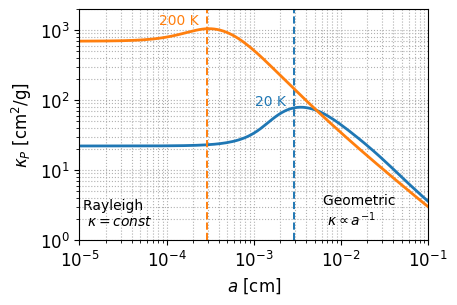

In [4]:
fig, ax = plt.subplots()

for i, res in enumerate(results):
    color = f'C{i}'
    y = res['kappa_P']
    ax.loglog(a, y, lw=2, color=color)
    ax.axvline(res['a_transition'], color=color, ls='--', lw=1.4)

    # Put label left of the dashed line, evaluated on the curve at that x
    x_label = res['a_transition'] / 1.25
    x_label = np.clip(x_label, a[0] * 1.1, a[-1] / 1.1)
    logy_label = np.interp(np.log10(x_label), np.log10(a), np.log10(y))
    y_label = 10**logy_label

    ax.text(
        x_label,
        y_label * 1.08,
        f"{res['T']:.0f} K",
        color=color,
        fontsize=10,
        ha='right',
        va='bottom',
    )

ax.set_xlabel('$a$ [cm]')
ax.set_ylabel(r'$\kappa_P$ [cm$^2$/g]')
ax.text(0.01, 0.05, "Rayleigh \n $\kappa = const$", transform=ax.transAxes, fontsize=10, ha='left', va='bottom',)
ax.text(0.7, 0.05, "Geometric \n $\kappa \propto a^{-1}$", transform=ax.transAxes, fontsize=10, ha='left', va='bottom',)
# ax.set_title(r'Planck mean opacity vs grain size ($a = \\lambda_\\mathrm{char}/2\\pi$, ' + lambda_label + ')')
ax.grid(True, which='both', ls=':')
ax.set_xlim(1e-5, 1e-1)
ax.set_ylim(1e0, 2e3)
plt.savefig('planck_opacity_vs_a.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [5]:
# Optional: inspect or export values
# np.savetxt('kappa_planck_vs_a_T100K.txt', np.column_stack([a, kappa_P]), header='a_cm kappaP_cm2_per_g')
np.column_stack([a, kappa_P])[:10]

array([[1.00000000e-05, 6.96950564e+02],
       [1.08436597e-05, 6.97151334e+02],
       [1.17584955e-05, 6.97387177e+02],
       [1.27505124e-05, 6.97664035e+02],
       [1.38262217e-05, 6.97989005e+02],
       [1.49926843e-05, 6.98370393e+02],
       [1.62575567e-05, 6.98817919e+02],
       [1.76291412e-05, 6.99342957e+02],
       [1.91164408e-05, 6.99958794e+02],
       [2.07292178e-05, 7.00680973e+02]])

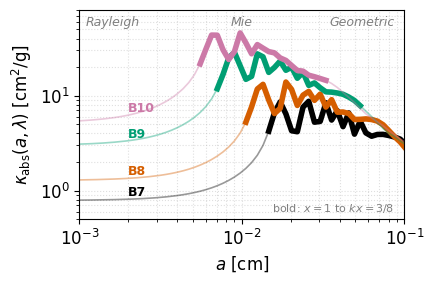

In [6]:
import contextlib, io

# Absorption opacity vs grain size at ALMA Bands 7-10 (single-size grains)
# Band centers (approx.): B7=0.87 mm, B8=0.65 mm, B9=0.45 mm, B10=0.35 mm
alma_band_centers_mm = {
    'B7': 0.87,
    'B8': 0.65,
    'B9': 0.45,
    'B10': 0.35,
}

# Choose wet or dry opacity table; wet is used here by default.
use_dry = False
k_abs_use = k_abs_d if use_dry else k_abs_w

# Get the DSHARP mixed dielectric constants to read k(λ) for the Mie transition
_fm_ice = 0.0 if use_dry else 0.2
with contextlib.redirect_stdout(io.StringIO()):
    diel_mix, _ = opacity.get_dsharp_mix(fm_ice=_fm_ice)

# Wong (2011) colorblind-safe palette — no blue or yellow
cb_colors = ['#000000', '#D55E00', '#009E73', '#CC79A7']

# Label x-position: well to the left of the bold region (Rayleigh regime)
a_label = 2e-3

fig, ax = plt.subplots()

for i, (band, lam_mm) in enumerate(alma_band_centers_mm.items()):
    lam_cm_target = lam_mm * 1e-1
    i_lam = np.argmin(np.abs(lam - lam_cm_target))
    lam_cm = lam[i_lam]
    k_line = k_abs_use[:, i_lam]
    color = cb_colors[i]

    # Absorption Mie transition grain sizes:
    #   x = 1      →  a_lo = λ/(2π)
    #   kx = 3/8   →  a_hi = (3/8) λ/(2πk)
    _, k_im = diel_mix.nk(lam_cm)
    a_lo = lam_cm / (2.0 * np.pi)
    a_hi = (3.0 / 8.0) * lam_cm / (2.0 * np.pi * k_im)

    # Thin, faded line for the full curve
    ax.loglog(a, k_line, lw=1.2, color=color, alpha=0.4)

    # Bold segment between the two transitions
    mask = (a >= a_lo) & (a <= a_hi)
    ax.loglog(a[mask], k_line[mask], lw=4, color=color)

    # Band label on the left (Rayleigh) part of the curve
    k_at_label = 10.0 ** np.interp(np.log10(a_label), np.log10(a), np.log10(k_line))
    ax.text(a_label, k_at_label, band, color=color, fontsize=9,
            ha='left', va='bottom', fontweight='bold')

ax.set_xlabel('$a$ [cm]')
ax.set_ylabel(r'$\kappa_{\mathrm{abs}}(a,\lambda)$ [cm$^2$/g]')
ax.text(0.97, 0.02, r'bold: $x{=}1$ to $kx{=}3/8$',
        transform=ax.transAxes, fontsize=8, ha='right', va='bottom', color='gray')
ax.text(0.02, 0.97, 'Rayleigh', transform=ax.transAxes, fontsize=9,
        ha='left', va='top', color='gray', fontstyle='italic')
ax.text(0.50, 0.97, 'Mie', transform=ax.transAxes, fontsize=9,
        ha='center', va='top', color='gray', fontstyle='italic')
ax.text(0.97, 0.97, 'Geometric', transform=ax.transAxes, fontsize=9,
        ha='right', va='top', color='gray', fontstyle='italic')
ax.grid(True, which='both', ls=':', alpha=0.4)
ax.set_xlim(1e-3, 1e-1)
ax.set_ylim(5e-1, 80)
plt.tight_layout()
plt.show()

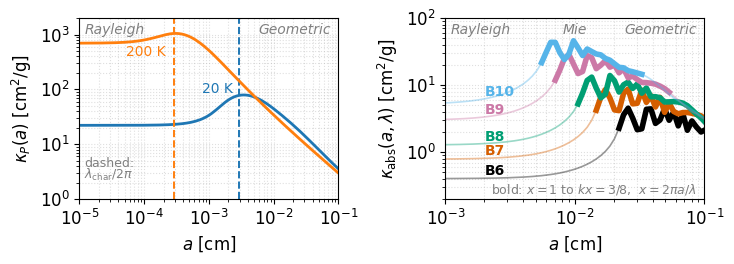

In [10]:
import contextlib, io

# ── shared style ──────────────────────────────────────────────────────────────
# Left panel (Planck mean): two temperatures, default C0/C1
planck_colors = ['C0', 'C1']
# Right panel (ALMA bands): Wong colorblind-safe, no blue/yellow
cb_colors = ['#000000', '#D55E00', '#009E73', '#CC79A7', '#56B4E9']

# in-plot fonts (+1 size from previous)
label_fs = 10
note_fs = 9

alma_band_centers_mm = {'B6': 1.3, 'B7': 0.87, 'B8': 0.65, 'B9': 0.45, 'B10': 0.35}

use_dry = False
k_abs_use = k_abs_d if use_dry else k_abs_w
_fm_ice = 0.0 if use_dry else 0.2
with contextlib.redirect_stdout(io.StringIO()):
    diel_mix, _ = opacity.get_dsharp_mix(fm_ice=_fm_ice)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7.5, 2.8))

# ── Left panel: Planck mean opacity ──────────────────────────────────────────
for i, res in enumerate(results):
    color = planck_colors[i]
    y = res['kappa_P']
    ax0.loglog(a, y, lw=2, color=color)
    ax0.axvline(res['a_transition'], color=color, ls='--', lw=1.4)

    x_lbl = np.clip(res['a_transition'] / 1.25, a[0] * 1.1, a[-1] / 1.1)
    y_lbl = 10 ** np.interp(np.log10(x_lbl), np.log10(a), np.log10(y))
    if np.isclose(res['T'], 200.0):
        # place 200 K lower and slightly left to keep it clear of curve/regime labels
        ax0.text(x_lbl / 1.08, y_lbl / 1.6, f"{res['T']:.0f} K",
                 color=color, fontsize=label_fs, ha='right', va='top')
    else:
        ax0.text(x_lbl, y_lbl * 1.08, f"{res['T']:.0f} K",
                 color=color, fontsize=label_fs, ha='right', va='bottom')

ax0.set_xlabel('$a$ [cm]')
ax0.set_ylabel(r'$\kappa_P(a)$ [cm$^2$/g]')
ax0.set_xlim(1e-5, 1e-1)
ax0.set_ylim(1e0, 2e3)
ax0.grid(True, which='both', ls=':', alpha=0.4)
# keep labels inside axes so they do not overlap panel title
ax0.text(0.02, 0.97, 'Rayleigh', transform=ax0.transAxes, fontsize=label_fs,
         ha='left', va='top', color='gray', fontstyle='italic')
# Removed "Mie" label on left panel per request
ax0.text(0.97, 0.97, 'Geometric', transform=ax0.transAxes, fontsize=label_fs,
         ha='right', va='top', color='gray', fontstyle='italic')
# Move dashed annotation to left and split into two lines to avoid vertical dashed lines
ax0.text(0.02, 0.16, 'dashed:',
         transform=ax0.transAxes, fontsize=note_fs, ha='left', va='bottom', color='gray')
ax0.text(0.02, 0.09, r'$\lambda_\mathrm{char}/2\pi$',
         transform=ax0.transAxes, fontsize=note_fs, ha='left', va='bottom', color='gray')
#ax0.set_title('(a) Planck mean opacity', fontsize=10, loc='left')

# ── Right panel: absorption opacity at ALMA bands ────────────────────────────
a_label = 2e-3
for i, (band, lam_mm) in enumerate(alma_band_centers_mm.items()):
    i_lam = np.argmin(np.abs(lam - lam_mm * 1e-1))
    lam_cm = lam[i_lam]
    k_line = k_abs_use[:, i_lam]
    color = cb_colors[i]

    _, k_im = diel_mix.nk(lam_cm)
    a_lo = lam_cm / (2.0 * np.pi)
    a_hi = (3.0 / 8.0) * lam_cm / (2.0 * np.pi * k_im)

    ax1.loglog(a, k_line, lw=1.2, color=color, alpha=0.4)
    mask = (a >= a_lo) & (a <= a_hi)
    ax1.loglog(a[mask], k_line[mask], lw=4, color=color)

    k_at_lbl = 10.0 ** np.interp(np.log10(a_label), np.log10(a), np.log10(k_line))
    ax1.text(a_label, k_at_lbl, band, color=color, fontsize=label_fs,
             ha='left', va='bottom', fontweight='bold')

ax1.set_xlabel('$a$ [cm]')
ax1.set_ylabel(r'$\kappa_{\mathrm{abs}}(a,\lambda)$ [cm$^2$/g]')
ax1.set_xlim(1e-3, 1e-1)
ax1.set_ylim(2e-1, 100)
ax1.grid(True, which='both', ls=':', alpha=0.4)
# keep labels inside axes so they do not overlap panel title
ax1.text(0.02, 0.97, 'Rayleigh', transform=ax1.transAxes, fontsize=label_fs,
         ha='left', va='top', color='gray', fontstyle='italic')
ax1.text(0.50, 0.97, 'Mie', transform=ax1.transAxes, fontsize=label_fs,
         ha='center', va='top', color='gray', fontstyle='italic')
ax1.text(0.97, 0.97, 'Geometric', transform=ax1.transAxes, fontsize=label_fs,
         ha='right', va='top', color='gray', fontstyle='italic')
ax1.text(0.97, 0.01, r'bold: $x{=}1$ to $kx{=}3/8$,  $x{=}2\pi a/\lambda$',
         transform=ax1.transAxes, fontsize=note_fs, ha='right', va='bottom', color='gray')
#ax1.set_title('(b) Single-size absorption opacity', fontsize=10, loc='left')

#plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.savefig('opacity_combined.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
